# Heart disease model

## Load & understand the data

### Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)



### load dataset

In [4]:
df = pd.read_csv("../data/heart_disease_health_indicators_BRFSS2015.csv")

In [5]:
df.shape

(253680, 22)

In [6]:
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [7]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [10]:
df.isnull().sum()

HeartDiseaseorAttack    0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
Diabetes                0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(23899)

In [15]:
df = df.drop_duplicates()


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,229781.0,0.103216,0.304241,0.0,0.0,0.0,0.0,1.0
HighBP,229781.0,0.454441,0.497921,0.0,0.0,0.0,1.0,1.0
HighChol,229781.0,0.441760,0.496598,0.0,0.0,0.0,1.0,1.0
CholCheck,229781.0,0.959535,0.197047,0.0,1.0,1.0,1.0,1.0
BMI,229781.0,28.685670,6.786360,12.0,24.0,27.0,32.0,98.0
Smoker,229781.0,0.465661,0.498821,0.0,0.0,0.0,1.0,1.0
Stroke,229781.0,0.044756,0.206767,0.0,0.0,0.0,0.0,1.0
Diabetes,229781.0,0.325627,0.724623,0.0,0.0,0.0,0.0,2.0
PhysActivity,229781.0,0.733355,0.442206,0.0,0.0,1.0,1.0,1.0
Fruits,229781.0,0.612966,0.487073,0.0,0.0,1.0,1.0,1.0


In [17]:
print(
    df["HeartDiseaseorAttack"]
    .value_counts(normalize=True)
    .mul(100)
)

HeartDiseaseorAttack
0.0    89.678433
1.0    10.321567
Name: proportion, dtype: float64


## Exploratory Data Analysis (EDA)

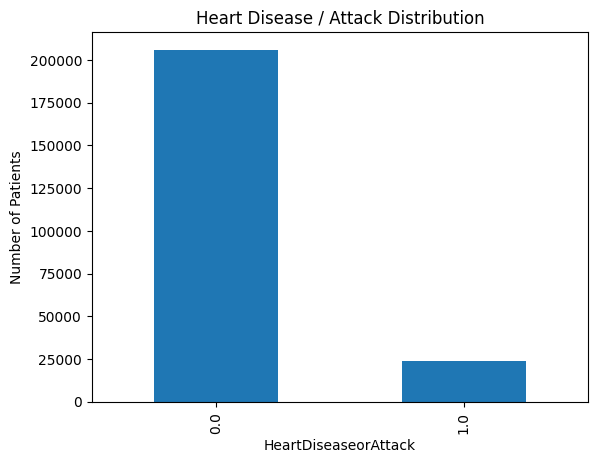

In [18]:
df["HeartDiseaseorAttack"].value_counts().plot(
    kind="bar"
)

plt.title("Heart Disease / Attack Distribution")
plt.xlabel("HeartDiseaseorAttack")
plt.ylabel("Number of Patients")
plt.show()

In [19]:
target_counts = df["HeartDiseaseorAttack"].value_counts()

print(target_counts)

print(
    df["HeartDiseaseorAttack"]
    .value_counts(normalize=True) * 100
)

HeartDiseaseorAttack
0.0    206064
1.0     23717
Name: count, dtype: int64
HeartDiseaseorAttack
0.0    89.678433
1.0    10.321567
Name: proportion, dtype: float64


In [20]:
correlations = (
    df.corr(numeric_only=True)["HeartDiseaseorAttack"]
    .sort_values(ascending=False)
)

print(correlations)

HeartDiseaseorAttack    1.000000
GenHlth                 0.246411
Age                     0.223626
DiffWalk                0.202779
HighBP                  0.201271
Stroke                  0.198863
HighChol                0.176279
Diabetes                0.170816
PhysHlth                0.170473
Smoker                  0.105154
Sex                     0.089717
MentHlth                0.052756
CholCheck               0.049995
BMI                     0.039926
AnyHealthcare           0.025899
NoDocbcCost             0.022076
Fruits                 -0.007128
Veggies                -0.027330
HvyAlcoholConsump      -0.035453
PhysActivity           -0.073267
Education              -0.082466
Income                 -0.122908
Name: HeartDiseaseorAttack, dtype: float64


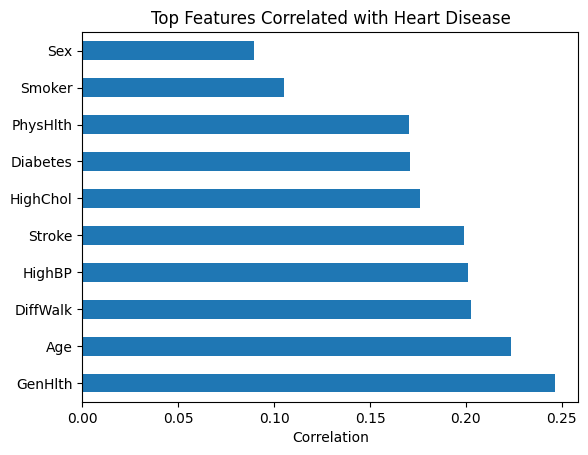

In [21]:
top_corr = correlations.drop("HeartDiseaseorAttack").head(10)

top_corr.plot(kind="barh")

plt.title("Top Features Correlated with Heart Disease")
plt.xlabel("Correlation")
plt.show()

In [22]:
print(df["BMI"].describe())

count    229781.00000
mean         28.68567
std           6.78636
min          12.00000
25%          24.00000
50%          27.00000
75%          32.00000
max          98.00000
Name: BMI, dtype: float64


In [23]:
df.groupby("HeartDiseaseorAttack")["BMI"].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,,,,,,,,
0.0,206064.0,28.593748,6.783536,12.0,24.0,27.0,32.0,98.0
1.0,23717.0,29.484336,6.758575,12.0,25.0,28.0,33.0,98.0


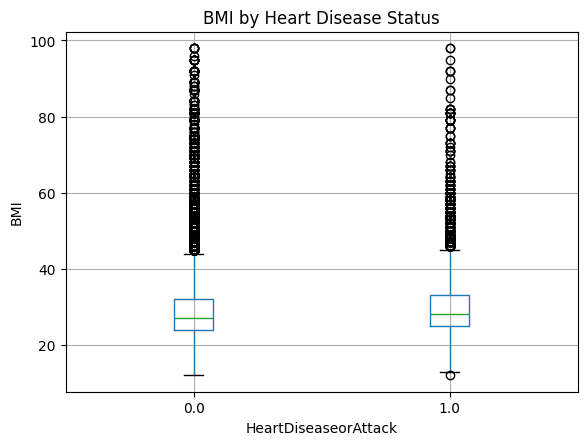

In [24]:
df.boxplot(
    column="BMI",
    by="HeartDiseaseorAttack"
)

plt.title("BMI by Heart Disease Status")
plt.suptitle("")
plt.xlabel("HeartDiseaseorAttack")
plt.ylabel("BMI")

plt.show()

In [25]:
important_features = [
    "HighBP",
    "HighChol",
    "Stroke",
    "Diabetes",
    "Smoker",
    "DiffWalk"
]

for col in important_features:
    print(f"\n{col}")
    print(
        df.groupby(col)["HeartDiseaseorAttack"]
        .mean()
    )


HighBP
HighBP
0.0    0.047328
1.0    0.170309
Name: HeartDiseaseorAttack, dtype: float64

HighChol
HighChol
0.0    0.055507
1.0    0.163504
Name: HeartDiseaseorAttack, dtype: float64

Stroke
Stroke
0.0    0.09012
1.0    0.38273
Name: HeartDiseaseorAttack, dtype: float64

Diabetes
Diabetes
0.0    0.079961
1.0    0.143444
2.0    0.223837
Name: HeartDiseaseorAttack, dtype: float64

Smoker
Smoker
0.0    0.073350
1.0    0.137486
Name: HeartDiseaseorAttack, dtype: float64

DiffWalk
DiffWalk
0.0    0.073773
1.0    0.232487
Name: HeartDiseaseorAttack, dtype: float64


In [26]:
binary_cols = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

for col in binary_cols:
    print(f"\n===== {col} =====")
    print(
        df.groupby(col)["HeartDiseaseorAttack"]
        .agg(["count", "mean"])
    )


===== HighBP =====
         count      mean
HighBP                  
0.0     125359  0.047328
1.0     104422  0.170309

===== HighChol =====
           count      mean
HighChol                  
0.0       128273  0.055507
1.0       101508  0.163504

===== CholCheck =====
            count      mean
CholCheck                  
0.0          9298  0.029146
1.0        220483  0.106339

===== Smoker =====
         count      mean
Smoker                  
0.0     122781  0.073350
1.0     107000  0.137486

===== Stroke =====
         count     mean
Stroke                 
0.0     219497  0.09012
1.0      10284  0.38273

===== PhysActivity =====
               count      mean
PhysActivity                  
0.0            61270  0.140183
1.0           168511  0.089775

===== Fruits =====
         count      mean
Fruits                  
0.0      88933  0.105945
1.0     140848  0.101492

===== Veggies =====
          count      mean
Veggies                  
0.0       47148  0.119581
1.0      1

In [27]:
ordinal_cols = [
    "GenHlth",
    "MentHlth",
    "PhysHlth",
    "Age",
    "Education",
    "Income",
    "Diabetes"
]

for col in ordinal_cols:
    print(f"\n===== {col} =====")
    print(df.groupby(col)["HeartDiseaseorAttack"].agg(["count", "mean"]))


===== GenHlth =====
         count      mean
GenHlth                 
1.0      34907  0.028905
2.0      77536  0.052066
3.0      73714  0.106371
4.0      31546  0.213149
5.0      12078  0.339957

===== MentHlth =====
           count      mean
MentHlth                  
0.0       152623  0.102403
1.0         8309  0.059574
2.0        12697  0.075215
3.0         7302  0.081621
4.0         3774  0.086116
5.0         8913  0.091103
6.0          988  0.115385
7.0         3090  0.086408
8.0          639  0.101721
9.0           91  0.065934
10.0        6352  0.110359
11.0          41  0.097561
12.0         398  0.120603
13.0          41  0.121951
14.0        1167  0.104542
15.0        5501  0.132703
16.0          88  0.147727
17.0          54  0.129630
18.0          97  0.144330
19.0          16  0.250000
20.0        3362  0.139500
21.0         227  0.171806
22.0          63  0.142857
23.0          38  0.078947
24.0          33  0.181818
25.0        1188  0.152357
26.0          45  0.155556

## Data preprocessing